## Import the CIFAR-10


In [1]:
from google.colab import files
uploaded = files.upload()

Saving cifar-10-python.tar.gz to cifar-10-python.tar.gz


In [3]:
# libs needed
import tarfile
import pickle

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim


## Load the data


In [104]:
with tarfile.open("cifar-10-python.tar.gz", "r:gz") as tar:
    tar.extractall()

# from https://www.cs.toronto.edu/~kriz/cifar.html
# Using the unpickle function, each of the bach files contains a dictionary with the following contents:
#   data --> a 10000x3072 numpy array of uint8's.
#       - Each row of the array stores a 32x32 colour image.
#       - Where the first 1024 entries contain the red channel, then 1024 for green, and then 1024 for blue
#       - The image is stored in row-major order, so the first 32 entries of the array are red channel values of the first row of the image
# SÅ data[i] indeholder 3 arrays af 1024 hver --> [ R (1024 values), G (1024 values), B (1024 values) ]
#

#   labels --> a list of 10000 numbers in the range 0-9
#       - The number at index i indicates the label of the i'th image in the array data

def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

/tmp/ipykernel_839/1944249754.py:2: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall()


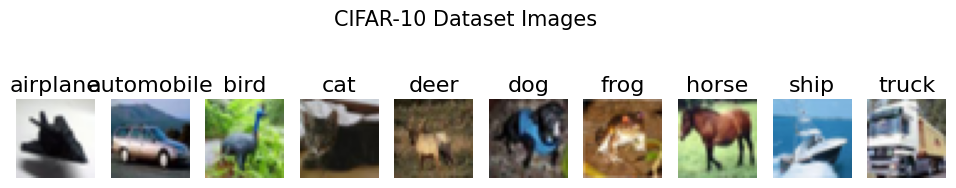

In [209]:
x_train = [] # the data
y_train = [] # the labels

for i in range(1,6):
  dict_train = unpickle(f'cifar-10-batches-py/data_batch_{i}')
  x_train.append(dict_train[b'data'])
  y_train.append(dict_train[b'labels'])

# Make them a long list instead of a list of lists
x_train = np.concatenate(x_train)
y_train = np.concatenate(y_train)

# The test data
dict_test = unpickle(f'cifar-10-batches-py/test_batch')
x_test = dict_test[b'data']
y_test = dict_test[b'labels']

# reshape so we get 50000,3,32,32 --> https://github.com/n-kostadinov/cnn-image-classification-cifar-10-from-scratch/blob/master/cnn-image-classification-cifar-10-from-scratch.ipynb

#features = batch['data'].reshape((len(batch['data']), 3, 32, 32)).transpose(0, 2, 3, 1)
x_train = x_train.reshape(-1, 3, 32, 32)   # (N, C, H, W)
x_train = x_train.transpose(0, 2, 3, 1)    # (N, H, W, C)

x_test = x_test.reshape(-1, 3, 32, 32)
x_test = x_test.transpose(0, 2, 3, 1)


# total size
n_train = x_train.shape[0]
n_test = x_test.shape[0]
n_total = n_train + n_test

# ------------------------------------------------------------
# pick one example of each digit
# ------------------------------------------------------------
examples = []

for digit in range(10):
    idx = np.where(y_train == digit)[0][0]
    examples.append(x_train[idx])

# ------------------------------------------------------------
# create figure
# ------------------------------------------------------------
fig = plt.figure(figsize=(12,5))

gs = fig.add_gridspec(2, 10, height_ratios=[1,1.2])

# title
fig.suptitle("CIFAR-10 Dataset Images", fontsize=15)

classes = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']
# ------------------------------------------------------------
# row of example digits
# ------------------------------------------------------------
for i in range(10):
    ax = fig.add_subplot(gs[0,i])

    ax.imshow(examples[i])
    # ax.set_title(str(i), fontsize=16)
    ax.set_title(str(classes[i]), fontsize=16)
    ax.axis("off")


# Setting up the CNN
